<h1>Fine-tune Gemma 4:E4B with QLoRA for Sentiment Analysis</h1>


# Introduction

In this notebook, we will experiment with a **Gemma 4** model - will test with a sentiment analysis task.
Here are the steps:

* Load a dataset with sentiments  
* Process it to create balanced train, evaluation and test sets and prepare prompts for LLM
* Define evaluation function
* Test Gemma 4 model without fine-tuning with prediction of sentiments
* Evaluate (using the test set) the fine-tuned model

## Sources for this Notebook

This Notebook is based entirely on two other notebooks:
* [Fine-tune Llama 3 for sentiment analysis](https://www.kaggle.com/code/lucamassaron/fine-tune-llama-3-for-sentiment-analysis) by Luca Massaron
* [Fine-tune Open LLaMA - 81% on Financial Sentiments](https://www.kaggle.com/code/pardeep19singh/fine-tune-open-llama-81-on-financial-sentiments/) by Pardeep Singh

## Data used

The dataset used is [Financial Sentiment Analysis](https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis). It combines two sources of data (FiQA, Financial PhraseBank), providing financial sentences, with sentiments added. It can be used to adapt models for sentiment analysis with specialization in financial domain. 

# Prerequisites

We will install the resources needed for importing the libraries (with the correct versions).

In [1]:
!pip install -q -U \
    transformers \
    datasets \
    accelerate \
    evaluate \
    bitsandbytes \
    trl \
    peft \
    sentencepiece

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf 24.8.3 requires cubinlinker, which is not installed.
cudf 24.8.3 requires cupy-cuda11x>=12.0.0, which is not installed.
cudf 24.8.3 requires ptxcompiler, which is not installed.
cuml 24.8.0 requires cupy-cuda11x>=12.0.0, which is not installed.
dask-cudf 24.8.3 requires cupy-cuda11x>=12.0.0, which is not installed.
apache-beam 2.46.0 requires cloudpickle~=2.2.1, but you have cloudpickle 3.0.0 which is incompatible.
apache-beam 2.46.0 requires dill<0.3.2,>=0.3.1.1, but you have dill 0.3.8 which is incompatible.
apache-beam 2.46.0 requires numpy<1.25.0,>=1.14.3, but you have numpy 1.26.4 which is incompatible.
apache-beam 2.46.0 requires pyarrow<10.0.0,>=3.0.0, but you have pyarrow 23.0.1 which is incompatible.
beatrix-jupyterlab 2024.66.154055 requires jupyterlab~=3.6.0, but you have jupyterlab 4.2.5 which is 

# Import packages

In [2]:
import torch
import transformers
import datasets
import trl
import peft
import bitsandbytes

print("torch", torch.__version__)
print("transformers", transformers.__version__)
print("datasets", datasets.__version__)
print("trl", trl.__version__)
print("peft", peft.__version__)
print("bitsandbytes", bitsandbytes.__version__)

torch 2.4.0
transformers 5.5.0
datasets 4.8.4
trl 1.0.0
peft 0.18.1
bitsandbytes 0.49.2


In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, AutoProcessor, TrainingArguments
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
import kagglehub

In [5]:
print(f"pytorch version {torch.__version__}")

pytorch version 2.4.0


In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"working on {device}")

working on cuda:0


Disabling two features in PyTorch related to memory efficiency and speed during operations on the Graphics Processing Unit (GPU) specifically for the scaled dot product attention (SDPA) function.

In [7]:
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_flash_sdp(False)

# Load the data

In [8]:
filename = "/kaggle/input/financial-sentiment-analysis/data.csv"

df = pd.read_csv(filename, 
                 encoding="utf-8", encoding_errors="replace")

In [9]:
df.columns = ["text", "sentiment"]

In [10]:
df.head()

,text,sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


Sample from each type of sentiment.

In [11]:
X_train = list()
X_test = list()
for sentiment in ["positive", "neutral", "negative"]:
    train, test  = train_test_split(df[df.sentiment==sentiment], 
                                    train_size=300,
                                    test_size=300, 
                                    random_state=42)
    X_train.append(train)
    X_test.append(test)

X_train = pd.concat(X_train).sample(frac=1, random_state=10)
X_test = pd.concat(X_test)

eval_idx = [idx for idx in df.index if idx not in list(X_train.index) + list(X_test.index)]
X_eval = df[df.index.isin(eval_idx)]
X_eval = (X_eval
          .groupby('sentiment', group_keys=False)
          .apply(lambda x: x.sample(n=50, random_state=10, replace=True)))
X_train = X_train.reset_index(drop=True)

/tmp/ipykernel_24/2194390274.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=50, random_state=10, replace=True)))


Let's check we got this right.

In [12]:
X_train.shape, X_eval.shape, X_test.shape

((900, 2), (150, 2), (900, 2))

In [13]:
def generate_prompt(data_point):
    return f"""
            Analyze the sentiment of the news headline enclosed in square brackets, 
            determine if it is positive, neutral, or negative, and return the answer as 
            the corresponding sentiment label "positive" or "neutral" or "negative".

            [{data_point["text"]}] = {data_point["sentiment"]}
            """.strip()

def generate_test_prompt(data_point):
    return f"""
            Analyze the sentiment of the news headline enclosed in square brackets, 
            determine if it is positive, neutral, or negative, and return the answer as 
            the corresponding sentiment label "positive" or "neutral" or "negative".

            [{data_point["text"]}] = """.strip()


In [14]:
X_train = pd.DataFrame(X_train.apply(generate_prompt, axis=1), 
                       columns=["text"])
X_eval = pd.DataFrame(X_eval.apply(generate_prompt, axis=1), 
                      columns=["text"])

y_true = X_test.sentiment
X_test = pd.DataFrame(X_test.apply(generate_test_prompt, axis=1), columns=["text"])

train_data = Dataset.from_pandas(X_train)
eval_data = Dataset.from_pandas(X_eval)

Next we create a function to evaluate the results from our sentiment model. The function performs the following steps:

1. Maps the sentiment labels to a numerical representation, where 2 represents positive, 1 represents neutral, and 0 represents negative.
2. Calculates the accuracy of the model on the test data.
3. Generates an accuracy report for each sentiment label.
4. Generates a classification report for the model.
5. Generates a confusion matrix for the model.

In [15]:
def evaluate(y_true, y_pred):
    labels = ['positive', 'neutral', 'negative']
    mapping = {'positive': 2, 'neutral': 1, 'none':1, 'negative': 0}
    def map_func(x):
        return mapping.get(x, 1)
    
    y_true = np.vectorize(map_func)(y_true)
    y_pred = np.vectorize(map_func)(y_pred)

    # Class labels
    class_labels = ['negative', 'neutral', 'positive']

    # Calculate accuracy
    accuracy = accuracy_score(y_true=y_true, y_pred=y_pred)
    print(f'Accuracy: {accuracy:.3f}')
    
    # Generate accuracy report
    unique_labels = set(y_true)  # Get unique labels
    
    for label in unique_labels:
        label_indices = [i for i in range(len(y_true)) 
                         if y_true[i] == label]
        label_y_true = [y_true[i] for i in label_indices]
        label_y_pred = [y_pred[i] for i in label_indices]
        accuracy = accuracy_score(label_y_true, label_y_pred)
        print(f'Accuracy for label {label}: {accuracy:.3f}')
        
    # Generate classification report
    class_report = classification_report(y_true=y_true, y_pred=y_pred, target_names=class_labels)
    print('\nClassification Report:')
    print(class_report)
    
    # Generate confusion matrix
    conf_matrix = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=[0, 1, 2])
    print('\nConfusion Matrix:')
    print(conf_matrix)

    # Create a heatmap
    plt.figure(figsize=(6, 5))
   
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges", xticklabels=class_labels, yticklabels=class_labels)
    
    # Add labels and title
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

## Load the Gemma 4 model

In [16]:
import torch
from transformers import AutoProcessor, AutoModelForCausalLM, BitsAndBytesConfig

model_name = "google/gemma-4/transformers/gemma-4-e2b-it"
MODEL_PATH = kagglehub.model_download(model_name)

processor = AutoProcessor.from_pretrained(MODEL_PATH)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.bfloat16,
    device_map="auto"
)

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

# Testing the Gemma 4 model without fine-tuning


In the next cell, we set a function for predicting sentiments from news headline using the Gemma 4 language model. The function takes four  arguments:
* df: A Pandas DataFrame containing the news headlines to be predicted.
* model: The Gemma model language model.
* processor: the processor (from transformers) that we initialized together with the model.
* batch_size: the batch size for the batches for which we perform inference.

The function works as follows:
* Batch-process the prompts
* Return the y_pred list.


By using batch inference we speed-up the process


In [17]:
from tqdm import tqdm
import torch

def predict_batch(df, model, processor, batch_size=8):
    y_pred = []

    texts = df["text"].tolist()

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]

        # Build chat prompts
        messages = [
            [{"role": "user", "content": f"Classify sentiment: {text}"}]
            for text in batch
        ]

        # Apply chat template
        prompts = [
            processor.apply_chat_template(
                m,
                tokenize=False,
                add_generation_prompt=True,
                enable_thinking=False
            )
            for m in messages
        ]

        # Tokenize batch
        inputs = processor(
            text=prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(model.device)

        input_len = inputs["input_ids"].shape[1]

        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=5,
                do_sample=False,   # deterministic
            )

        decoded = processor.batch_decode(
            outputs[:, input_len:],
            skip_special_tokens=True
        )

        # Parse predictions
        for out in decoded:
            out = out.lower()

            if "positive" in out:
                y_pred.append("positive")
            elif "negative" in out:
                y_pred.append("negative")
            elif "neutral" in out:
                y_pred.append("neutral")
            else:
                y_pred.append("none")

    return y_pred

In [18]:
y_pred = predict_batch(X_test, model, processor, batch_size=8)

100%|██████████| 113/113 [03:27<00:00,  1.84s/it]


Accuracy: 0.684
Accuracy for label 0: 0.830
Accuracy for label 1: 0.823
Accuracy for label 2: 0.400

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.83      0.83       300
     neutral       0.53      0.82      0.64       300
    positive       0.91      0.40      0.56       300

    accuracy                           0.68       900
   macro avg       0.76      0.68      0.68       900
weighted avg       0.76      0.68      0.68       900


Confusion Matrix:
[[249  49   2]
 [ 43 247  10]
 [  9 171 120]]


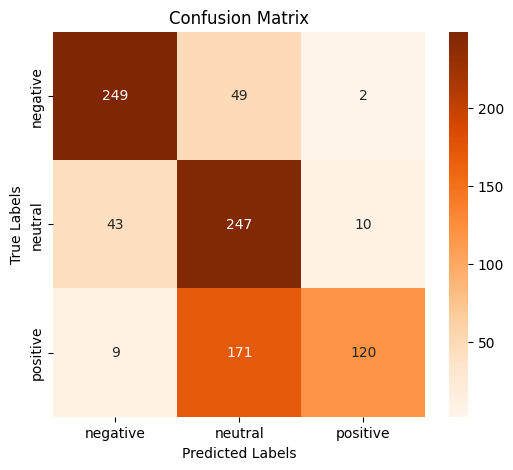

In [19]:
evaluate(y_true, y_pred)

# Conclusions

The native performance of the **Gemma 4** model is quite good. We can further improve the performance by fine-tuning.